# Introduction
This notebook explores information and insights of raw data.
## Importing libraries
NumPy, Pandas and Matplotlib are imported for initial data analysis, extracting statistical insights, and plotting correlations of potential features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

Now, we read the raw data by using Pandas

In [2]:
icloud_path = os.path.expanduser('~/Library/Mobile Documents/com~apple~CloudDocs/Documents/MyLearning/MachineLearning/Project1/')
os.chdir(icloud_path)
os.getcwd()

'/Users/dushyant/Documents/MyLearning/MachineLearning/Project1'

In [3]:
train_data = pd.read_csv("data/raw/train.csv")
test_data = pd.read_csv("data/raw/test.csv")

In [4]:
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


It shows that are there are 563 features. But how many rows/data points?

In [5]:
train_data.shape[0]

7352

In [6]:
test_data.shape[0]

2947

Now we know that there are 7352 data points from train data and 2947 data points from test data. So what would be the ratio of train-test split?

In [7]:
test_ratio = test_data.shape[0] / (train_data.shape[0] + test_data.shape[0])
print("The test ratio is ", test_ratio)

The test ratio is  0.28614428585299545


There are 563 features, which are very challenging to plot and estimate correlation manually - these include either plotting columns, or using correlation measures for all the features.
Rather, the following approaches could be adopted -
1. Calculating correltion matrix, however, this would also result in a matrix of shape 563 X 563, which is a huge matrix to analyse.
2. Reducing dimensionality for visualisation, either by setting a threshold wherein if a correlation measure is above this threshold, those features are considered. The other option is to sort correlation measure in descending order and consider top-N correlations.
3. Dropping redundant features - by removing highly correlated features.
4. Using dimensionality reduction, such as PCA or t-SNE, to visualise.

In [8]:
# (1): Calculating correlation matrix, and importing the matrix as a separate csv
train_data_float = train_data.select_dtypes(include=float)
print(train_data_float.shape[1])
corr_matrix = train_data_float.corr()
print(corr_matrix)

561
                                      tBodyAcc-mean()-X  tBodyAcc-mean()-Y  \
tBodyAcc-mean()-X                              1.000000           0.148061   
tBodyAcc-mean()-Y                              0.148061           1.000000   
tBodyAcc-mean()-Z                             -0.256952          -0.078769   
tBodyAcc-std()-X                               0.000619          -0.045160   
tBodyAcc-std()-Y                              -0.021903          -0.044920   
...                                                 ...                ...   
angle(tBodyGyroMean,gravityMean)               0.037444           0.017967   
angle(tBodyGyroJerkMean,gravityMean)           0.028844           0.075679   
angle(X,gravityMean)                          -0.035257          -0.005309   
angle(Y,gravityMean)                           0.034371           0.001053   
angle(Z,gravityMean)                           0.028242          -0.013903   

                                      tBodyAcc-mean()-Z  tB

In [9]:
# (2)A: Setting threshold
# Get pairs of features with high correlation
high_corr = corr_matrix.abs() > 0.8
np.fill_diagonal(high_corr.values, False)  # exclude self-correlation

# Show which pairs exceed the threshold
high_corr_pairs = high_corr[high_corr].stack()
print(high_corr_pairs)

tBodyAcc-std()-X      tBodyAcc-std()-Y          True
                      tBodyAcc-std()-Z          True
                      tBodyAcc-mad()-X          True
                      tBodyAcc-mad()-Y          True
                      tBodyAcc-mad()-Z          True
                                                ... 
angle(Y,gravityMean)  tGravityAcc-energy()-X    True
                      tGravityAcc-energy()-Y    True
angle(Z,gravityMean)  tGravityAcc-mean()-Z      True
                      tGravityAcc-max()-Z       True
                      tGravityAcc-min()-Z       True
Length: 46116, dtype: object


In [10]:
# (2)B: Considering top-N correlations

In [11]:
# (3): Dropping redundant features
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.95)]
train_data_reduced = train_data_float.drop(columns=to_drop)
print(train_data_reduced)

      tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
0              0.288585          -0.020294          -0.132905   
1              0.278419          -0.016411          -0.123520   
2              0.279653          -0.019467          -0.113462   
3              0.279174          -0.026201          -0.123283   
4              0.276629          -0.016570          -0.115362   
...                 ...                ...                ...   
7347           0.299665          -0.057193          -0.181233   
7348           0.273853          -0.007749          -0.147468   
7349           0.273387          -0.017011          -0.045022   
7350           0.289654          -0.018843          -0.158281   
7351           0.351503          -0.012423          -0.203867   

      tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-max()-Z  \
0            -0.995279         -0.983111         -0.913526         -0.744413   
1            -0.998245         -0.975300         -0.960322 

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0               STANDING
1               STANDING
2               STANDING
3               STANDING
4               STANDING
              ...       
7347    WALKING_UPSTAIRS
7348    WALKING_UPSTAIRS
7349    WALKING_UPSTAIRS
7350    WALKING_UPSTAIRS
7351    WALKING_UPSTAIRS
Name: Activity, Length: 7352, dtype: object

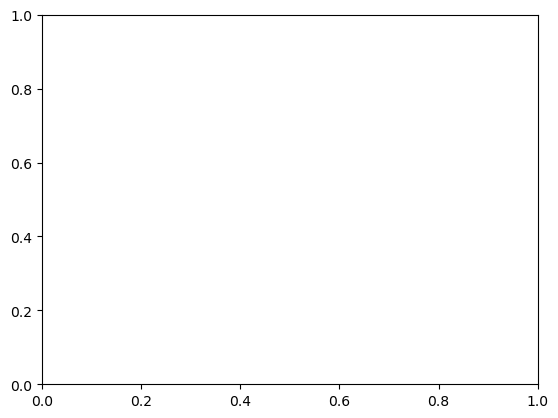

In [12]:
# (4): Using PCA for dimensionality reduction
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
components = pca.fit_transform(train_data.drop('Activity', axis=1))

plt.scatter(components[:, 0], components[:, 1], c=train_data['Activity'])
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA Projection')
plt.show()

In [13]:
X_train, y_train = train_data.iloc[:,:-1], train_data.iloc[:,-1]
X_test, y_test = test_data.iloc[:,:-1], test_data.iloc[:,-1]

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Create the SVM model
svm_model = SVC(kernel='linear', C=1.0, gamma='scale')  # You can change kernel to 'linear', 'poly', etc.

# Step 2: Fit the model on training data
svm_model.fit(X_train, y_train)

# Step 3: Predict on test data
y_pred = svm_model.predict(X_test)

# Step 4: Evaluate the performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9633525619273838
Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.96      0.89      0.92       491
          STANDING       0.90      0.97      0.94       532
           WALKING       0.95      1.00      0.97       496
WALKING_DOWNSTAIRS       0.99      0.98      0.98       420
  WALKING_UPSTAIRS       0.98      0.95      0.97       471

          accuracy                           0.96      2947
         macro avg       0.97      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



In [15]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[537,   0,   0,   0,   0,   0],
       [  0, 435,  55,   0,   0,   1],
       [  0,  16, 516,   0,   0,   0],
       [  0,   0,   0, 494,   1,   1],
       [  0,   0,   0,   4, 410,   6],
       [  0,   0,   0,  22,   2, 447]])

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Step 1: Create the model
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
# You can also try: criterion='entropy'

# Step 2: Fit the model
dt_model.fit(X_train, y_train)

# Step 3: Predict on test data
y_pred = dt_model.predict(X_test)

# Step 4: Evaluate the performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.838479809976247
Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.78      0.81      0.80       491
          STANDING       0.82      0.79      0.80       532
           WALKING       0.78      0.95      0.85       496
WALKING_DOWNSTAIRS       0.94      0.63      0.76       420
  WALKING_UPSTAIRS       0.76      0.80      0.78       471

          accuracy                           0.84      2947
         macro avg       0.85      0.83      0.83      2947
      weighted avg       0.85      0.84      0.84      2947



In [17]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[537,   0,   0,   0,   0,   0],
       [  0, 400,  91,   0,   0,   0],
       [  0, 113, 419,   0,   0,   0],
       [  0,   0,   0, 470,  10,  16],
       [  0,   0,   0,  49, 266, 105],
       [  0,   0,   0,  86,   6, 379]])

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Create the model
rf_model = RandomForestClassifier(
    n_estimators=250,       # Number of trees
    max_depth=None,         # Max depth of each tree
    random_state=42,        # For reproducibility
    n_jobs=-1               # Use all available cores
)

# Step 2: Fit the model
rf_model.fit(X_train, y_train)

# Step 3: Predict
y_pred = rf_model.predict(X_test)

# Step 4: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9277231082456736
Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.90      0.97      0.93       496
WALKING_DOWNSTAIRS       0.96      0.85      0.90       420
  WALKING_UPSTAIRS       0.89      0.92      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [20]:
!pip install xgboost

In [21]:
from xgboost import XGBClassifier

model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

ModuleNotFoundError: No module named 'xgboost'

In [23]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9389209365456397
Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      0.96      0.98       537
           SITTING       0.97      0.86      0.91       491
          STANDING       0.84      0.98      0.90       532
           WALKING       0.93      0.99      0.96       496
WALKING_DOWNSTAIRS       0.98      0.92      0.95       420
  WALKING_UPSTAIRS       0.94      0.93      0.94       471

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [25]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(n_estimators=100)),
    #('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')),
    ('mlp', MLPClassifier(max_iter=500))
], voting='soft')

ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9477434679334917
Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      0.96      0.98       537
           SITTING       0.98      0.86      0.92       491
          STANDING       0.85      0.98      0.92       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.95      0.97       420
  WALKING_UPSTAIRS       0.95      0.94      0.94       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [26]:
confusion_matrix(y_test, y_pred)

array([[514,   0,  23,   0,   0,   0],
       [  0, 422,  66,   0,   0,   3],
       [  0,   8, 524,   0,   0,   0],
       [  0,   0,   0, 493,   2,   1],
       [  0,   0,   0,   3, 398,  19],
       [  0,   0,   0,  29,   0, 442]])